In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Let us build rank-k approximation for a matrix

A = np.array([[3, 1],
              [6, 2],
              [9, 3]])

print("Rank of the matrix A is ", np.linalg.matrix_rank(A))

# Now for such a matrix with rank 1 if we build a rank-1 approximation 
# we should be preserving the enitre matrix as is


# Compute svd
U, sv, Vt = np.linalg.svd(A)

rank = 1
U_k = U[:, :rank]              
sv_k = sv[:rank]               
Vt_k = Vt[:rank, :]  


# Finding rank-1 approximation fro matrix A
A_k = U_k @ np.diag(sv_k) @ Vt_k

# This should be as is matrix A as we are preseving the enitre rank
print("Are the rank-1 approximation and the original matrix the same ? ", np.allclose(A_k,A))

Rank of the matrix A is  1
Are the rank-1 approximation and the original matrix the same ?  True


In [6]:
# Now there is another approach of finding the rank-k approximation of a matrix
# call the outerproduct

u1 = U[:, 0]          # first column of U
v1 = Vt[0, :]         # first row of Vᵀ
s1 = sv[0]            # first singular value


# Outer product: u1 (column) × v1 (row)
# np.outer does this directly
outer = np.outer(u1, v1)
A_k_outer = s1 * outer

print("\nMatches slicing approach?", np.allclose(A_k, A_k_outer))


Matches slicing approach? True


In [20]:
# Now we will create a different matrix with data pattern variations in it

np.random.seed(42)
B = np.random.randn(6, 6) * 10
B = np.round(B, 1)

print("B:\n", B)

U, sv, Vt = np.linalg.svd(B)
sv =np.round(sv,2)

print("\n Singular values", sv)

# The rank of theamtrix is six so the matrix is full ranked
# The singular values are sorted in descendin order the most prominent variation at the first and so on and so forth


def rank_k_approximation(M, k):
    """Build the rank-k SVD approximation of matrix M."""
    U, sv, Vt = np.linalg.svd(M)
    U_k = U[:, :k]
    sv_k = sv[:k]
    Vt_k = Vt[:k, :]
    return U_k @ np.diag(sv_k) @ Vt_k


# Reconstruct B at different k values
for k in [1, 2, 3, 4, 5, 6]:
    B_k = rank_k_approximation(B, k)
    error = np.linalg.norm(B - B_k, 'fro')   # Frobenius norm of the error
    print(f"k = {k}: error = {error:.4f}")


# Notice the error reduces as the value of approximation increases from 1 to 6. And at the final k= 6 the error is zero



B:
 [[  5.   -1.4   6.5  15.2  -2.3  -2.3]
 [ 15.8   7.7  -4.7   5.4  -4.6  -4.7]
 [  2.4 -19.1 -17.2  -5.6 -10.1   3.1]
 [ -9.1 -14.1  14.7  -2.3   0.7 -14.2]
 [ -5.4   1.1 -11.5   3.8  -6.   -2.9]
 [ -6.   18.5  -0.1 -10.6   8.2 -12.2]]

 Singular values [34.85 29.71 25.24 16.4  12.3   1.55]
k = 1: error = 44.0698
k = 2: error = 32.5514
k = 3: error = 20.5610
k = 4: error = 12.4004
k = 5: error = 1.5519
k = 6: error = 0.0000


In [21]:
# Now let us verfiy the Eckart-young error formulae
# The formulae says: error of rank-k approximation = √(sum of squared discarded singular values)


print("k | empirical error | predicted error (formula)")
print("-" * 50)

for k in range(1, 7):
    # Empirical: actually compute the approximation and measure error
    B_k = rank_k_approximation(B, k)
    empirical_error = np.linalg.norm(B - B_k, 'fro')
    
    # Predicted: √(sum of squared discarded singular values)
    discarded = sv[k:]
    predicted_error = np.sqrt(np.sum(discarded ** 2))
    
    print(f"{k} | {empirical_error:.4f}          | {predicted_error:.4f}")


# The empirical error and the predicted error from the formulae are same



k | empirical error | predicted error (formula)
--------------------------------------------------
1 | 44.0698          | 44.0726
2 | 32.5514          | 32.5532
3 | 20.5610          | 20.5585
4 | 12.4004          | 12.3973
5 | 1.5519          | 1.5500
6 | 0.0000          | 0.0000


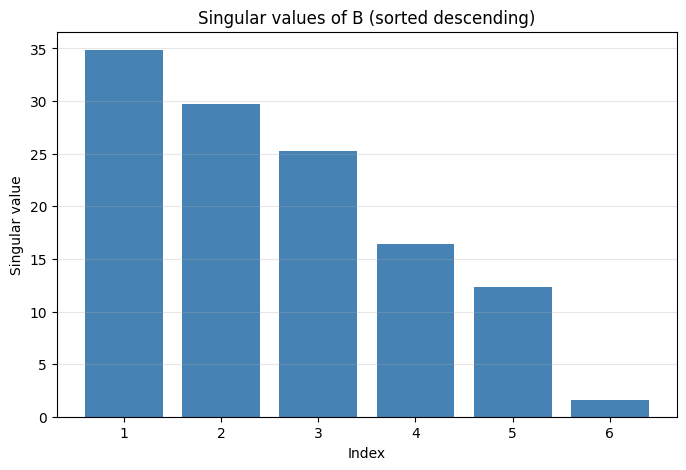

In [22]:
# Now let us visualzie the singular value distribution

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(sv) + 1), sv, color='steelblue')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.title('Singular values of B (sorted descending)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [23]:
# Let us now see the cumulative variance


total_variance = np.sum(sv ** 2)
cumulative_variance = np.cumsum(sv ** 2) / total_variance

print(cumulative_variance)

# You could see how for each K value the amount of information captured increases

[0.38471794 0.66432117 0.86611858 0.95131563 0.99923897 1.        ]
